<a href="https://colab.research.google.com/github/NateyLB/CMPE255Project/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)
## Mental Health & Crisis Signal Mining on Social Media
**CMPE 255 – Section 34, Spring 2026**

This notebook loads and explores the three Kaggle datasets used in this project:
1. **Reddit Mental Health Dataset** (`data_to_be_cleansed.csv`)
2. **Sentiment Analysis for Mental Health ** (`Combined Data.csv.csv`)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Load Datasets

In [ ]:
# Dataset 1: Reddit Mental Health
df_reddit = pd.read_csv('../data/data_to_be_cleansed.csv')
df_reddit = df_reddit.drop(columns=['Unnamed: 0'], errors='ignore')

# Dataset 2: Depression & Anxiety (Social Media)
df_text = pd.read_csv('../data/Combined Data.csv.csv')
df_text = df_text.drop(columns=['Unnamed: 0'], errors='ignore')

print(f'Reddit Mental Health: {df_reddit.shape}')
print(f'Depression & Anxiety: {df_text.shape}')

# Report nulls before dropping
print(f'\nNull text rows - Reddit: {df_reddit["text"].isnull().sum()}, Text: {df_text["post_text"].isnull().sum()}')

# Drop rows with null text
df_reddit = df_reddit.dropna(subset=['text'])
df_text = df_text.dropna(subset=['post_text'])

print(f'\nAfter dropping nulls:')
print(f'Reddit Mental Health: {df_reddit.shape}')
print(f'Dreaddit:             {df_dreaddit.shape}')
print(f'Depression & Anxiety: {df_text.shape}')

Reddit Mental Health: (5957, 3)
Dreaddit:             (3553, 116)
Depression & Anxiety: (20000, 10)

Null text rows - Reddit: 350, Dreaddit: 0, Twitter: 0

After dropping nulls:
Reddit Mental Health: (5607, 3)
Dreaddit:             (3553, 116)
Depression & Anxiety: (20000, 10)


## 2. Dataset 1 – Reddit Mental Health

In [ ]:
print('Columns:', df_reddit.columns.tolist())
print('\nShape:', df_reddit.shape)
print('\nNull counts:')
print(df_reddit.isnull().sum())
print('\nDuplicates:', df_reddit.duplicated().sum())
df_reddit.head(3)

Columns: ['text', 'title', 'target']

Shape: (5607, 3)

Null counts:
text      0
title     0
target    0
dtype: int64

Duplicates: 1172


,text,title,target
0,Welcome to /r/depression's check-in post - a p...,"Regular check-in post, with information about ...",1
1,We understand that most people who reply immed...,Our most-broken and least-understood rules is ...,1
2,Anyone else just miss physical touch? I crave ...,"I haven’t been touched, or even hugged, in so ...",1


Target value counts:
target
1    1202
4    1144
0    1099
2    1085
3    1077
Name: count, dtype: int64



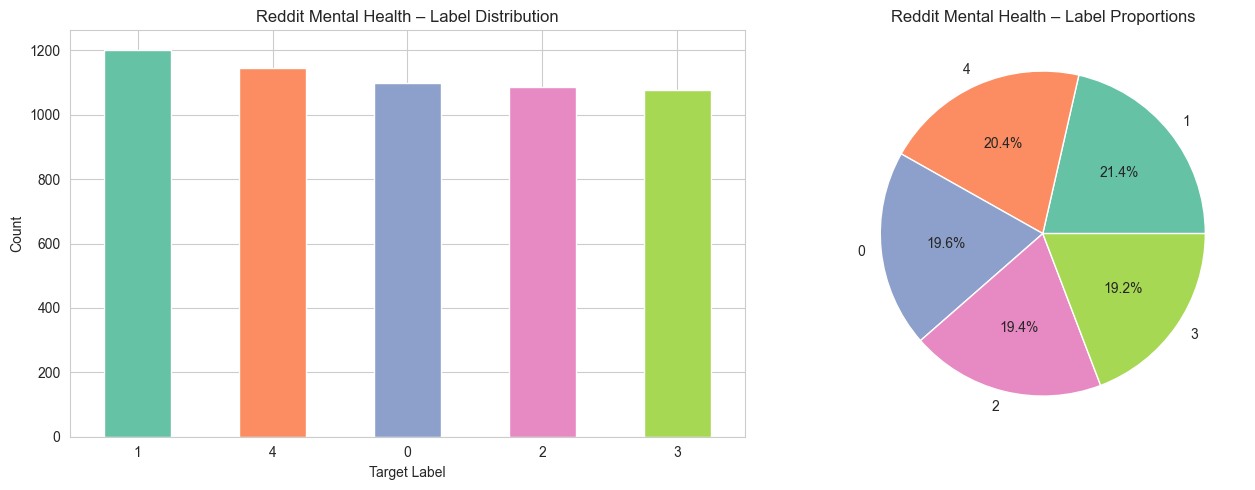

In [ ]:
# Target label distribution
print('Target value counts:')
print(df_reddit['target'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
df_reddit['target'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Reddit Mental Health – Label Distribution')
axes[0].set_xlabel('Target Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df_reddit['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Reddit Mental Health – Label Proportions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

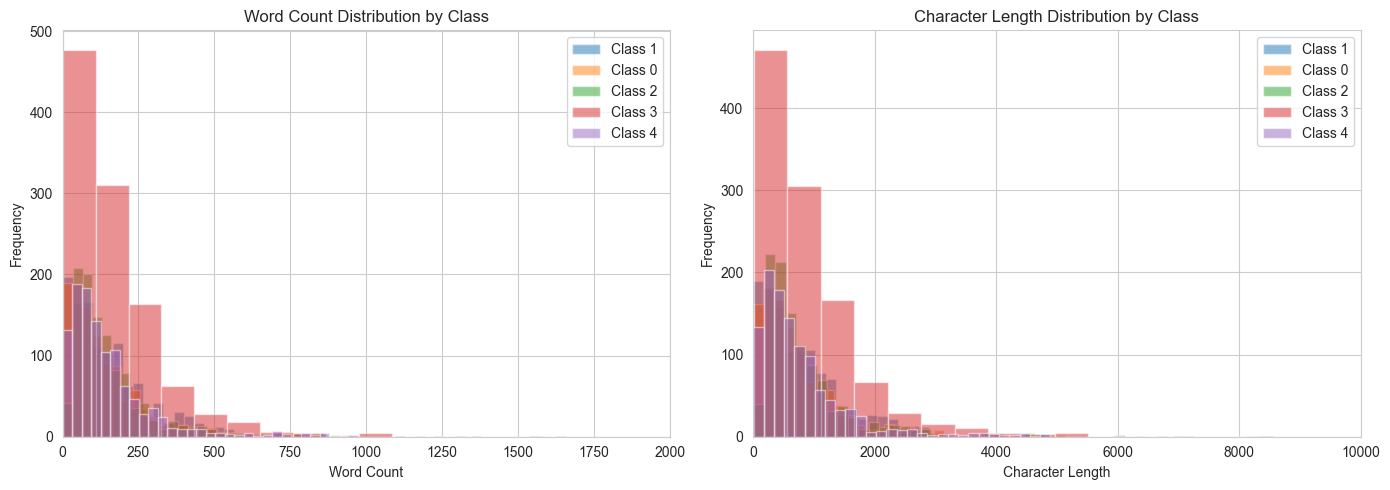

Word count statistics by class:
         count   mean    std  min   25%    50%    75%     max
target                                                       
0       1099.0  141.8  149.8  1.0  44.0  100.0  186.0  1586.0
1       1202.0  164.7  159.1  1.0  53.0  121.0  219.2  1657.0
2       1085.0  155.5  136.5  3.0  70.0  116.0  196.0  1575.0
3       1077.0  171.0  221.8  1.0  59.0  129.0  230.0  5411.0
4       1144.0  155.1  161.8  1.0  59.0  107.5  190.2  1567.0


In [ ]:
# Post length analysis
df_reddit['text_len'] = df_reddit['text'].astype(str).apply(len)
df_reddit['word_count'] = df_reddit['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label in df_reddit['target'].unique():
    subset = df_reddit[df_reddit['target'] == label]
    axes[0].hist(subset['word_count'], bins=50, alpha=0.5, label=f'Class {label}')
    axes[1].hist(subset['text_len'], bins=50, alpha=0.5, label=f'Class {label}')

axes[0].set_title('Word Count Distribution by Class')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 2000)

axes[1].set_title('Character Length Distribution by Class')
axes[1].set_xlabel('Character Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 10000)

plt.tight_layout()
plt.show()

print('Word count statistics by class:')
print(df_reddit.groupby('target')['word_count'].describe().round(1))

In [ ]:
# Sample posts per class
for label in sorted(df_reddit['target'].unique()):
    print(f'\n{"="*60}')
    print(f'TARGET = {label}')
    print(f'{"="*60}')
    sample = df_reddit[df_reddit['target'] == label].sample(2, random_state=42)
    for _, row in sample.iterrows():
        text = str(row['text'])[:300]
        print(f'\nTitle: {row.get("title", "N/A")}')
        print(f'Text: {text}...')
        print(f'Word count: {row["word_count"]}')


TARGET = 0

Title: Anyone here doing school while working full-time?
Text: I have two jobs and am finishing up my degree. There is never anytime where I can flip the switch off and relax. I’m always falling behind on deadlines unless I’m expending effort into academics for every waking second that I’m off work. 

Anybody else experience this? And if so, any tips for mainta...
Word count: 58

Title: Wanna Do a Stress quiz?
Text: Hello! 

I'm doing an assignment for my school about stress and I need reposnses. This survey is about the stressful situations many face throughout their lives. Although this survey may not be 100% accurate or realistic all I need are responses! And no worries this is 100% anonymous except for your...
Word count: 72

TARGET = 1

Title: Mental health help???
Text: I am finally looking to start getting help for my mental health. It has been a very long time coming and I just can't do it anymore. I believe I have several diagnoses, including ADHD, anxiety, depres

## 3. Dataset 2 – Dreaddit (Stress Analysis)

## 4. Dataset 3 – Depression & Anxiety on Social Media

In [ ]:
print('Columns:', df_text.columns.tolist())
print(f'\nShape: {df_text.shape}')
print(f'\nNull counts:')
print(df_text.isnull().sum())
print(f'\nDuplicates: {df_text.duplicated(subset=["post_text"]).sum()}')
df_text.head(3)

Columns: ['post_id', 'post_created', 'post_text', 'user_id', 'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label']

Shape: (20000, 10)

Null counts:
post_id         0
post_created    0
post_text       0
user_id         0
followers       0
friends         0
favourites      0
statuses        0
retweets        0
label           0
dtype: int64

Duplicates: 512


,post_id,post_created,post_text,user_id,followers,friends,favourites,statuses,retweets,label
0,637894677824413696,Sun Aug 30 07:48:37 +0000 2015,It's just over 2 years since I was diagnosed w...,1013187241,84,211,251,837,0,1
1,637890384576778240,Sun Aug 30 07:31:33 +0000 2015,"It's Sunday, I need a break, so I'm planning t...",1013187241,84,211,251,837,1,1
2,637749345908051968,Sat Aug 29 22:11:07 +0000 2015,Awake but tired. I need to sleep but my brain ...,1013187241,84,211,251,837,0,1


Label value counts:
label
1    10000
0    10000
Name: count, dtype: int64



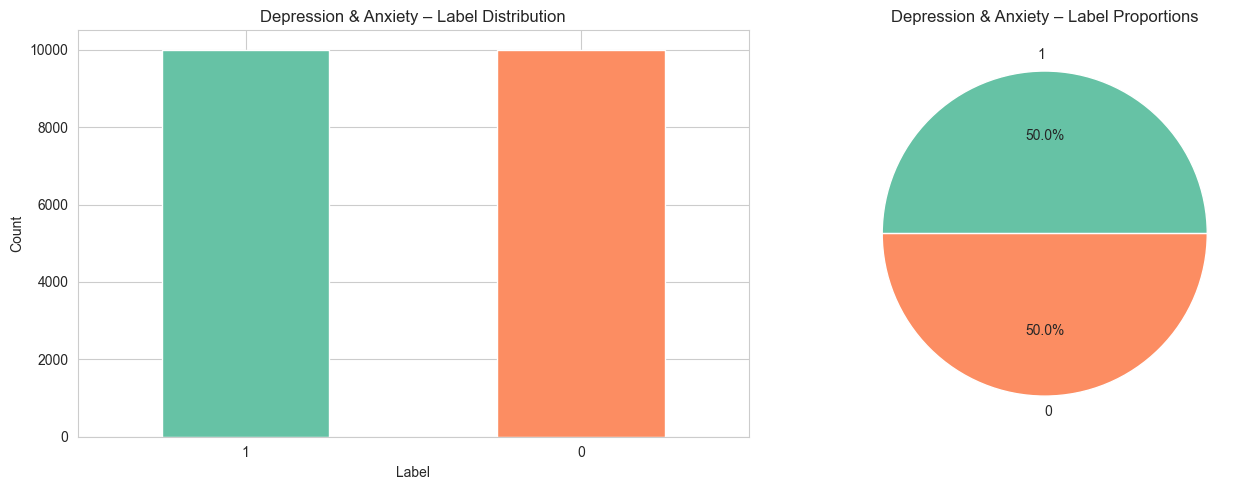

In [ ]:
# Label distribution
print('Label value counts:')
print(df_text['label'].value_counts())
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_text['label'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Depression & Anxiety – Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

df_text['label'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Depression & Anxiety – Label Proportions')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

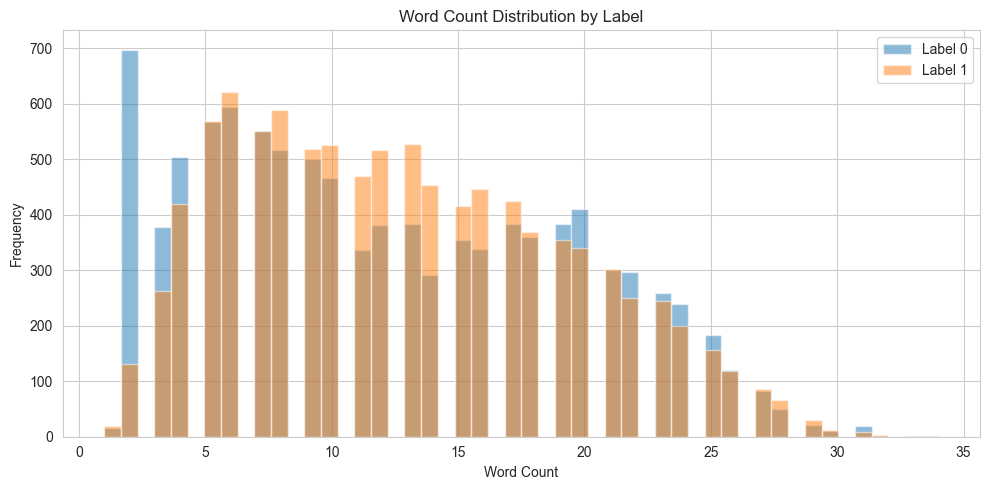

Word count statistics by label:


         count  mean  std  min  25%   50%   75%   max
label                                                
0      10000.0  12.2  7.2  1.0  6.0  11.0  18.0  34.0
1      10000.0  12.8  6.5  1.0  7.0  12.0  18.0  34.0


In [ ]:
# Post length analysis
df_text['word_count'] = df_text['post_text'].astype(str).apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(10, 5))
for label in sorted(df_text['label'].unique()):
    subset = df_text[df_text['label'] == label]
    ax.hist(subset['word_count'], bins=50, alpha=0.5, label=f'Label {label}')

ax.set_title('Word Count Distribution by Label')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print('Word count statistics by label:')
print(df_text.groupby('label')['word_count'].describe().round(1))

In [ ]:
# Sample posts
for label in sorted(df_text['label'].unique()):
    print(f'\n{"="*60}')
    print(f'LABEL = {label}')
    print(f'{"="*60}')
    sample = df_text[df_text['label'] == label].sample(2, random_state=42)
    for _, row in sample.iterrows():
        text = str(row['post_text'])[:300]
        print(f'\nText: {text}')
        print(f'Word count: {row["word_count"]}')


LABEL = 0

Text: @meifan13 NOT SEX TOYS GOD
Word count: 5

Text: @madywurt you're really living life rn
Word count: 6

LABEL = 1

Text: @LarryDocuments My entire year made with Harry and Louis next to each other ❤
Word count: 14

Text: RT @playbill: Here's the full list of @TheTonyAwards nominees. http://t.co/nLL87HkhI7 http://t.co/bUaKxmfsl8
Word count: 11


## 5. Cross-Dataset Summary

In [ ]:
summary = pd.DataFrame({
    'Dataset': ['Reddit Mental Health', 'Depression & Anxiety'],
    'Rows': [len(df_reddit), len(df_twitter)],
    'Text Column': ['text', 'text', 'post_text'],
    'Label Column': ['target', 'label', 'label'],
    'Unique Labels': [
        df_reddit['target'].nunique(),
        df_text['label'].nunique()
    ],
    'Avg Word Count': [
        df_reddit['word_count'].mean().round(1),
        df_text['word_count'].mean().round(1)
    ],
    'Null Text Rows': [
        df_reddit['text'].isnull().sum(),
        df_text['post_text'].isnull().sum()
    ]
})

print('Cross-Dataset Summary:')
print('=' * 80)
summary

Cross-Dataset Summary:


,Dataset,Rows,Text Column,Label Column,Unique Labels,Avg Word Count,Null Text Rows
0,Reddit Mental Health,5607,text,target,5,157.7,0
1,Dreaddit,3553,text,label,2,85.6,0
2,Depression & Anxiety,20000,post_text,label,2,12.5,0


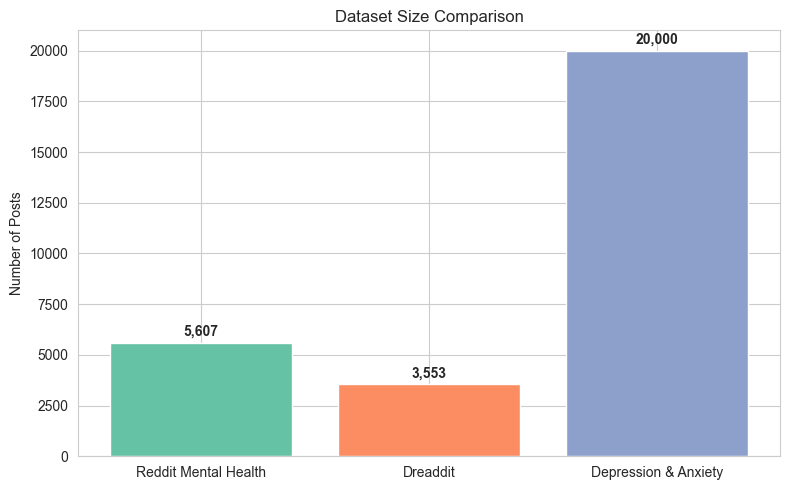


Total posts across all datasets: 29,160


In [ ]:
# Combined dataset size comparison
fig, ax = plt.subplots(figsize=(8, 5))
datasets = ['Reddit Mental Health', 'Depression & Anxiety']
sizes = [len(df_reddit), len(df_text)]
colors = sns.color_palette('Set2', 3)

bars = ax.bar(datasets, sizes, color=colors)
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 200,
            f'{size:,}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Dataset Size Comparison')
ax.set_ylabel('Number of Posts')
plt.tight_layout()
plt.show()

print(f'\nTotal posts across all datasets: {sum(sizes):,}')

## 6. Top Unigrams & Bigrams (Reddit Mental Health)

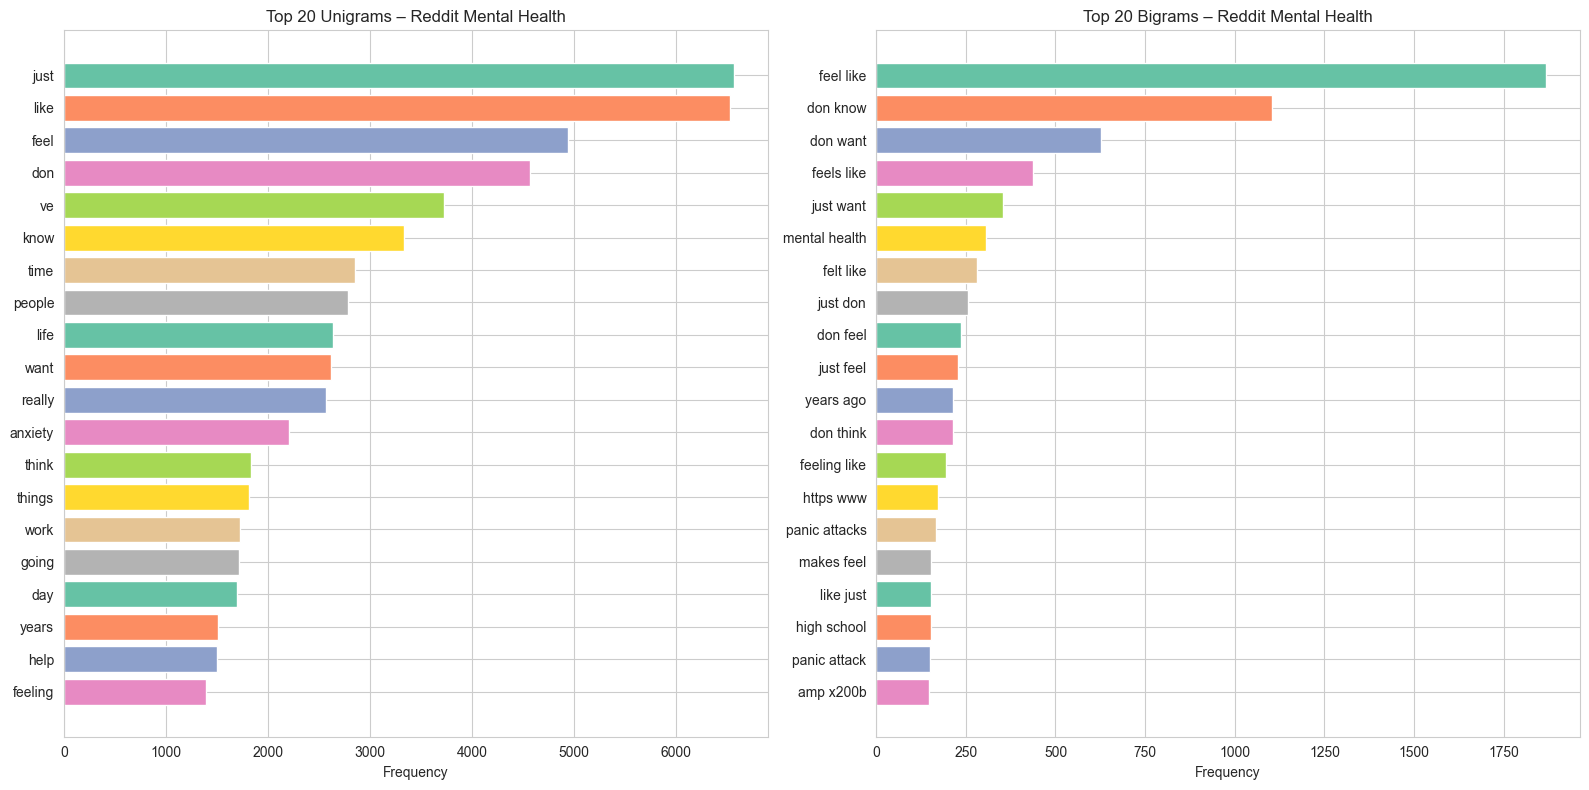

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(texts, n=1, top_k=20, title=''):
    """Plot top-k n-grams from a list of texts."""
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=top_k)
    bow = vec.fit_transform(texts.astype(str))
    sum_words = bow.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

    words, counts = zip(*words_freq)
    plt.barh(range(len(words)), counts, color=sns.color_palette('Set2', len(words)))
    plt.yticks(range(len(words)), words)
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.xlabel('Frequency')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plt.sca(axes[0])
plot_top_ngrams(df_reddit['text'], n=1, top_k=20, title='Top 20 Unigrams – Reddit Mental Health')

plt.sca(axes[1])
plot_top_ngrams(df_reddit['text'], n=2, top_k=20, title='Top 20 Bigrams – Reddit Mental Health')

plt.tight_layout()
plt.show()

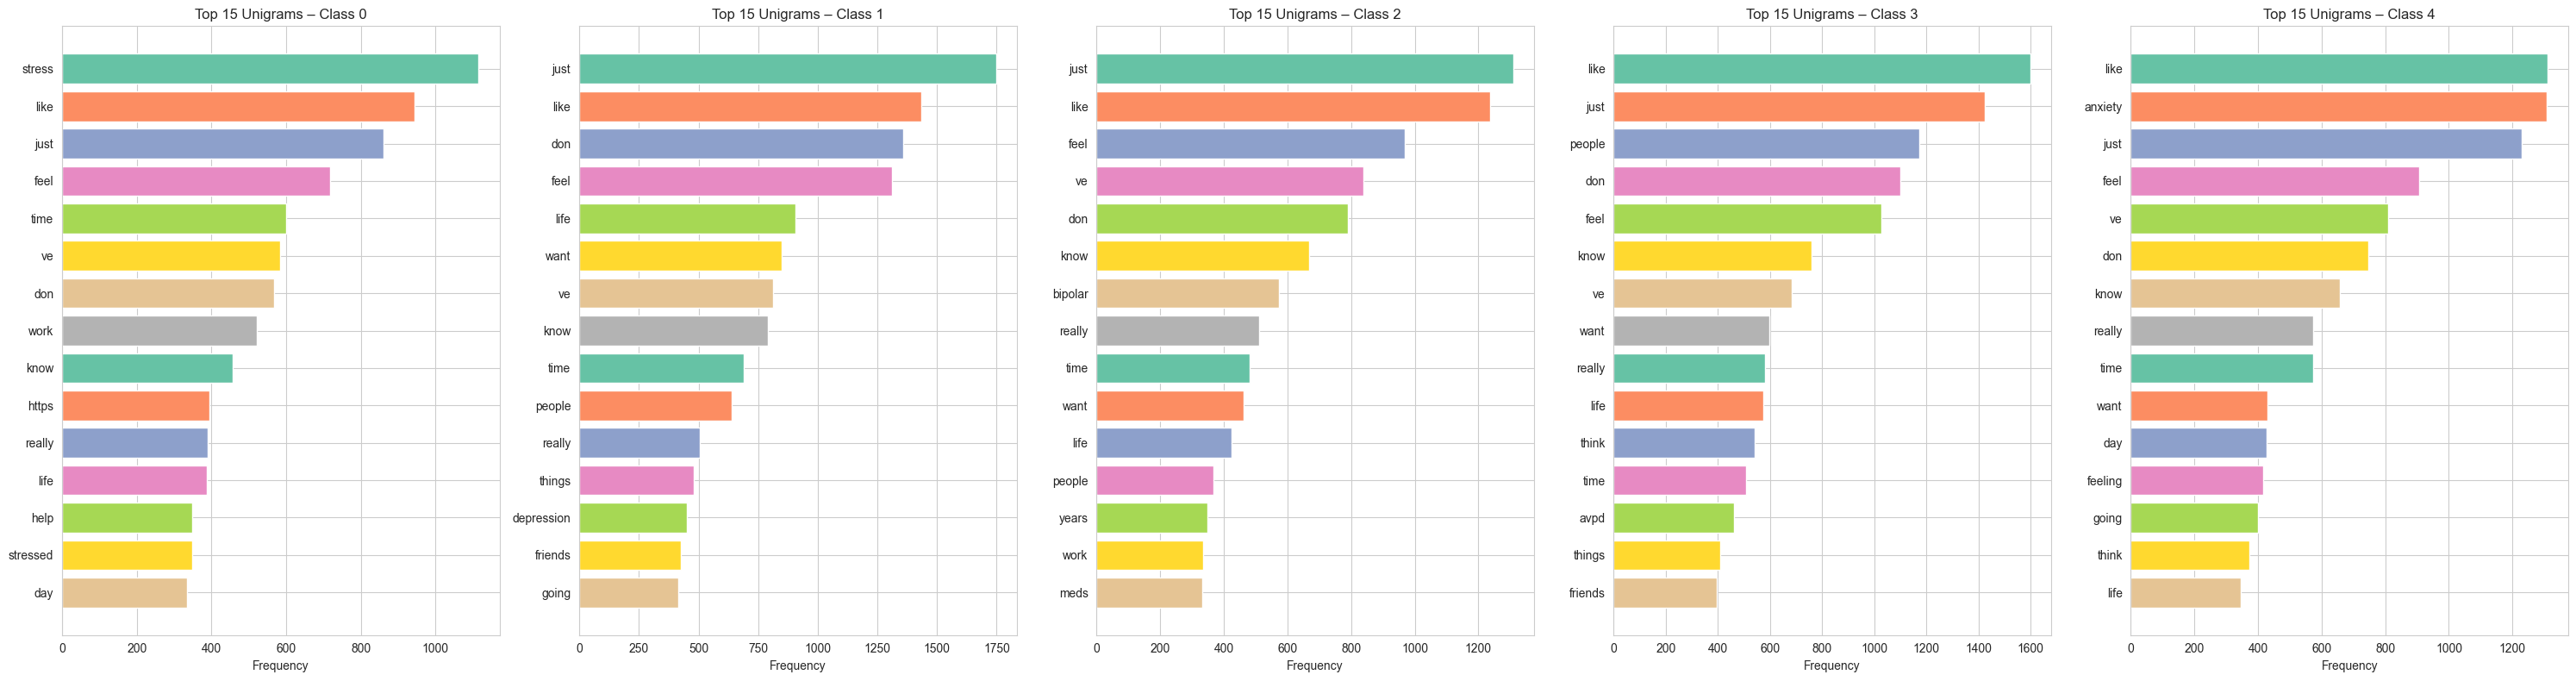

In [ ]:
# Top unigrams per class in Reddit Mental Health
unique_targets = sorted(df_reddit['target'].unique())
n_classes = len(unique_targets)
fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 8))

if n_classes == 1:
    axes = [axes]

for ax, label in zip(axes, unique_targets):
    plt.sca(ax)
    subset = df_reddit[df_reddit['target'] == label]['text']
    plot_top_ngrams(subset, n=1, top_k=15, title=f'Top 15 Unigrams – Class {label}')

plt.tight_layout()
plt.show()

## 7. Key Observations

### Initial Findings

- **Dataset sizes vary significantly**: The Reddit Mental Health dataset has ~6K posts, Dreaddit ~3.5K posts, and the Depression & Anxiety dataset ~20K posts, totaling ~29.5K posts across all three.
- **Class imbalance** needs to be addressed — label distributions are not uniform across datasets.
- **Post lengths differ** across datasets and classes, which motivates post-level statistical features.
- **Dreaddit** includes pre-computed LIWC features (116 columns), which can supplement our feature engineering.
- **The Depression & Anxiety dataset** is from Twitter, so posts are shorter than Reddit posts.

### Next Steps
1. Text cleaning (remove HTML, URLs, special characters, lowercase)
2. Handle class imbalance (SMOTE, class weights)
3. TF-IDF vectorization and feature engineering
4. Model training (Logistic Regression, SVM, XGBoost, DistilBERT)